Creating dataset with THREE DISTINCT PATTERNS...
  Class 0: Horizontal stripe (dark rows 1-2)
  Class 1: Vertical stripe   (dark cols 1-2)
  Class 2: Checkerboard      (alternating dark/bright)


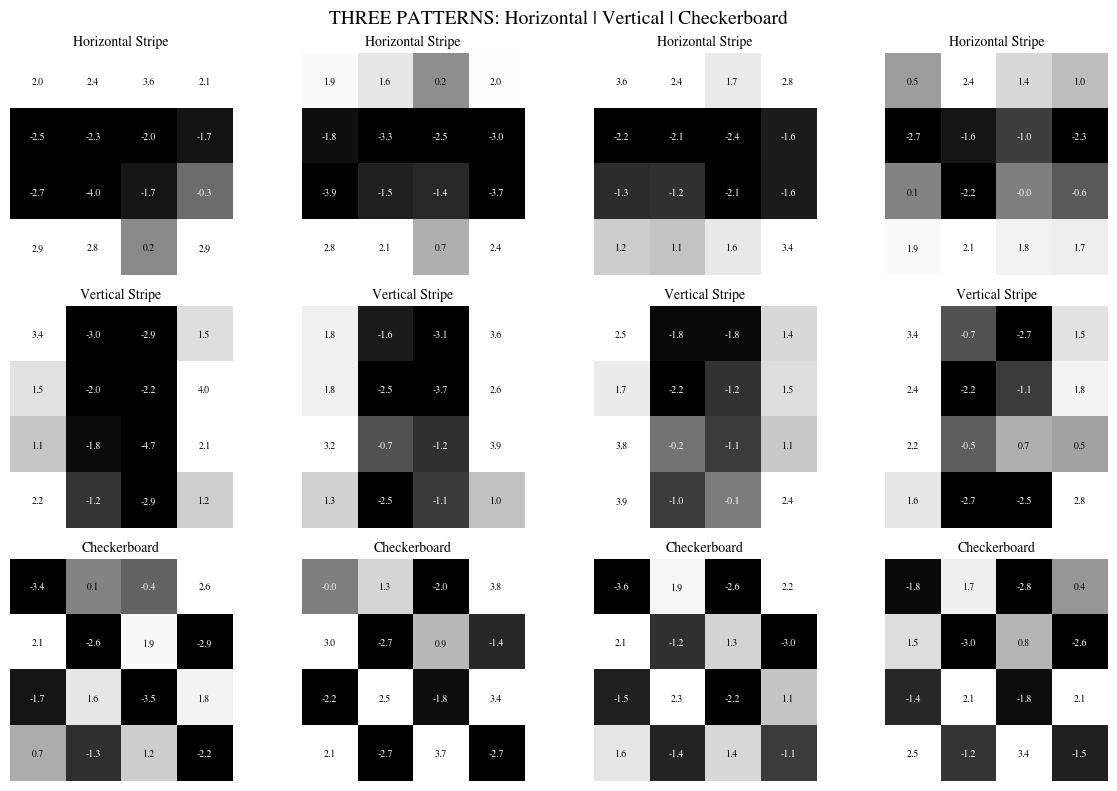


CNN CLASSIFICATION — optimizer: SGD
THREE PATTERNS: Horizontal | Vertical | Checkerboard
SEQUENTIAL PARAMETER INHERITANCE
Beta values: 300  (0.000 → 1.000)

Training β = 0.000000  (1/300)
  ✓ Random init (first model)
    Epoch 10, Loss: 0.0417
    Epoch 20, Loss: 0.0192
  Train loss: 0.0001  |  Test loss: 0.0002  |  Test acc: 100.0%  |  L2 norm (r0): 4.2131

Training β = 0.003344  (2/300)
  ✓ Weights from β = 0.000000
  ✓ Optimizer state inherited, weight_decay updated
    Epoch 10, Loss: 0.1010
    Epoch 20, Loss: 0.1268
  Train loss: 0.0014  |  Test loss: 0.0016  |  Test acc: 100.0%  |  L2 norm (r0): 3.3227

Training β = 0.006689  (3/300)
  ✓ Weights from β = 0.003344
  ✓ Optimizer state inherited, weight_decay updated
    Epoch 10, Loss: 0.2612
    Epoch 20, Loss: 0.2603
  Train loss: 0.0028  |  Test loss: 0.0030  |  Test acc: 100.0%  |  L2 norm (r0): 2.8098

Training β = 0.010033  (4/300)
  ✓ Weights from β = 0.006689
  ✓ Optimizer state inherited, weight_decay updated
    Epoch 

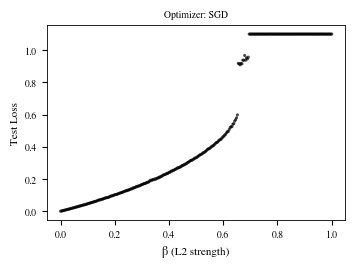

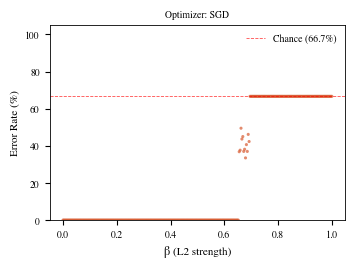

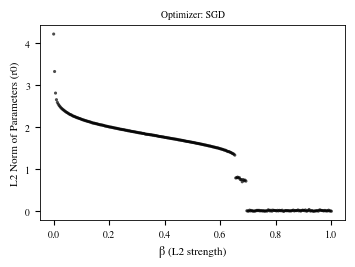

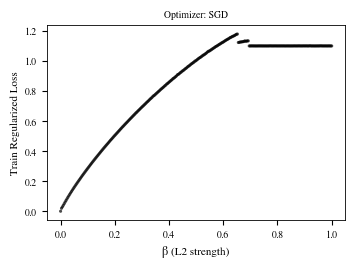


EXPERIMENT COMPLETE  —  optimizer: SGD
  Best β:          0.000000
  Best Test Acc:   100.00%
  Best Test Loss:  0.0002
  r0 at best β:    4.2131


In [6]:
"""
CNN L2 Experiment — THREE DISTINCT PATTERNS
Output CSV matches format: L2_strength, Train_Loss, Train_Reg_Loss, Test_Loss, Test_Accuracy, r_0

Class 0: Horizontal stripe  (dark band, rows 1-2)
Class 1: Vertical stripe    (dark band, cols 1-2)
Class 2: Checkerboard       (alternating dark/bright — clearly distinct from both stripes)

WITH SEQUENTIAL PARAMETER INHERITANCE + CHOOSABLE OPTIMIZER
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import copy

torch.manual_seed(42)
device = torch.device("cpu")

#==============================================================================
# OPTIMIZER CONFIGURATION — change this to switch optimizer
#==============================================================================

OPTIMIZER_NAME = "sgd"   # Options: "adam", "sgd", "rmsprop", "adamw"

def build_optimizer(model, beta, name=OPTIMIZER_NAME):
    name = name.lower()
    if name == "adam":
        return optim.Adam(model.parameters(), lr=0.01, weight_decay=beta)
    elif name == "adamw":
        return optim.AdamW(model.parameters(), lr=0.01, weight_decay=beta)
    elif name == "sgd":
        return optim.SGD(model.parameters(), lr=0.05, weight_decay=beta, momentum=0.0)
    elif name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=0.01, weight_decay=beta)
    else:
        raise ValueError(f"Unknown optimizer '{name}'. Choose from: adam, adamw, sgd, rmsprop")

def update_optimizer_weight_decay(optimizer, beta):
    for param_group in optimizer.param_groups:
        param_group['weight_decay'] = beta

#==============================================================================
# DATASET: THREE CLEARLY DISTINCT PATTERNS
#==============================================================================

def create_pattern_dataset(n_samples=2000):
    """
    All classes share a bright background (+2.0) with noise std=0.3.
    Dark features use -2.0 with noise std=0.2.

    Class 0: HORIZONTAL STRIPE — dark band in rows 1-2  (signal range ~ -2 in rows 1-2)
    Class 1: VERTICAL STRIPE   — dark band in cols 1-2  (signal range ~ -2 in cols 1-2)
    Class 2: CHECKERBOARD      — dark on (i+j) even, bright on (i+j) odd
                                 Maximally different from both stripes — no two
                                 adjacent cells share the same polarity.

    The three patterns are orthogonal in pixel space: no template overlap.
    """
    X = torch.zeros(n_samples, 1, 4, 4)
    y = torch.zeros(n_samples, dtype=torch.long)

    samples_per_class = n_samples // 3

    checkerboard_mask = torch.zeros(4, 4)
    for i in range(4):
        for j in range(4):
            checkerboard_mask[i, j] = 1 if (i + j) % 2 == 0 else 0

    for i in range(n_samples):
        class_id = min(i // samples_per_class, 2)

        # Start with bright background + independent noise per cell
        img = torch.ones(4, 4) * 2.0 + torch.randn(4, 4) * 0.9

        if class_id == 0:
            # Dark horizontal band: rows 1 and 2
            img[1:3, :] = -2.0 + torch.randn(2, 4) * 0.9

        elif class_id == 1:
            # Dark vertical band: cols 1 and 2
            img[:, 1:3] = -2.0 + torch.randn(4, 2) * 0.9

        else:
            # Checkerboard: dark where (i+j) is even, bright where (i+j) is odd
            for r in range(4):
                for c in range(4):
                    if (r + c) % 2 == 0:
                        img[r, c] = -2.0 + torch.randn(1).item() * 0.9
                    else:
                        img[r, c] =  2.0 + torch.randn(1).item() * 0.9

        X[i, 0] = img
        y[i] = class_id

    perm = torch.randperm(n_samples)
    return X[perm], y[perm]

#==============================================================================
# VISUALIZE THE THREE PATTERNS
#==============================================================================

def visualize_patterns(X, y):
    fig, axes = plt.subplots(3, 4, figsize=(12, 8))
    class_names = ["Horizontal Stripe", "Vertical Stripe", "Checkerboard"]

    for class_id in range(3):
        class_indices = (y == class_id).nonzero(as_tuple=True)[0]
        for col in range(4):
            idx = class_indices[col]
            img = X[idx, 0].numpy()
            ax = axes[class_id, col]
            ax.imshow(img, cmap='gray', vmin=-2, vmax=2, interpolation='nearest')
            ax.set_title(class_names[class_id], fontsize=10, fontweight='bold')
            ax.axis('off')
            for i in range(4):
                for j in range(4):
                    val = img[i, j]
                    color = 'white' if val < 0 else 'black'
                    ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                            fontsize=7, color=color, fontweight='bold')

    plt.suptitle('THREE PATTERNS: Horizontal | Vertical | Checkerboard',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("pattern_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()

#==============================================================================
# CREATE DATASETS
#==============================================================================

print("Creating dataset with THREE DISTINCT PATTERNS...")
print("  Class 0: Horizontal stripe (dark rows 1-2)")
print("  Class 1: Vertical stripe   (dark cols 1-2)")
print("  Class 2: Checkerboard      (alternating dark/bright)")

train_X, train_y = create_pattern_dataset(3000)
eval_X,  eval_y  = create_pattern_dataset(600)

train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=32, shuffle=True)
eval_loader  = DataLoader(TensorDataset(eval_X,  eval_y),  batch_size=32)

visualize_patterns(train_X, train_y)

#==============================================================================
# TINY CNN
#==============================================================================

class TinyCNNClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc    = nn.Linear(16, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

#==============================================================================
# EVALUATION HELPERS
#==============================================================================

def evaluate(model, loader):
    """Returns (avg cross-entropy loss, accuracy %) on loader."""
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_ce, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            logits = model(X)
            total_ce += criterion(logits, y).item() * X.size(0)
            _, predicted = torch.max(logits, 1)
            correct += (predicted == y).sum().item()
            total   += y.size(0)
    return total_ce / total, correct / total * 100   # loss, accuracy %

def compute_train_reg_loss(model, loader, beta, criterion):
    """Cross-entropy + beta * (sum of squared weights / 2) on loader."""
    model.eval()
    total_ce, total_n = 0.0, 0
    with torch.no_grad():
        for X, y in loader:
            total_ce += criterion(model(X), y).item() * X.size(0)
            total_n  += X.size(0)
    avg_ce = total_ce / total_n
    l2_reg = sum(torch.sum(p ** 2).item() for p in model.parameters()) / 2
    return avg_ce + beta * l2_reg

def compute_l2_norm(model):
    total = sum(torch.norm(p, 2).item() ** 2 for p in model.parameters())
    return np.sqrt(total)

#==============================================================================
# MAIN EXPERIMENT
#==============================================================================

beta_values = np.linspace(0, 1, 300)

print("\n" + "="*60)
print(f"CNN CLASSIFICATION — optimizer: {OPTIMIZER_NAME.upper()}")
print("THREE PATTERNS: Horizontal | Vertical | Checkerboard")
print("SEQUENTIAL PARAMETER INHERITANCE")
print(f"Beta values: {len(beta_values)}  ({beta_values[0]:.3f} → {beta_values[-1]:.3f})")
print("="*60)

results            = []
previous_model     = None
previous_optimizer = None
criterion          = nn.CrossEntropyLoss()

for idx, beta in enumerate(beta_values):
    print(f"\n{'='*50}")
    print(f"Training β = {beta:.6f}  ({idx+1}/{len(beta_values)})")

    model = TinyCNNClassifier(num_classes=3)

    if previous_model is not None:
        model.load_state_dict(previous_model.state_dict())
        print(f"  ✓ Weights from β = {beta_values[idx-1]:.6f}")
        optimizer = build_optimizer(model, beta)
        if previous_optimizer is not None:
            optimizer.load_state_dict(previous_optimizer.state_dict())
            update_optimizer_weight_decay(optimizer, beta)
            print(f"  ✓ Optimizer state inherited, weight_decay updated")
    else:
        optimizer = build_optimizer(model, beta)
        print(f"  ✓ Random init (first model)")

    # ── Training ──────────────────────────────────────────────────────────────
    for epoch in range(30):
        model.train()
        epoch_loss = 0.0
        for X, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if epoch % 10 == 0 and epoch > 0:
            print(f"    Epoch {epoch}, Loss: {epoch_loss:.4f}")

    # ── Evaluation ────────────────────────────────────────────────────────────
    train_loss, train_acc   = evaluate(model, train_loader)
    train_reg_loss          = compute_train_reg_loss(model, train_loader, beta, criterion)
    test_loss,  test_acc    = evaluate(model, eval_loader)
    r0                      = compute_l2_norm(model)

    results.append({
        'L2_strength':    beta,
        'Train_Loss':     train_loss,
        'Train_Reg_Loss': train_reg_loss,
        'Test_Loss':      test_loss,
        'Test_Accuracy':  test_acc,        # percentage, e.g. 87.5
        'r0':             r0,
    })

    print(f"  Train loss: {train_loss:.4f}  |  Test loss: {test_loss:.4f}"
          f"  |  Test acc: {test_acc:.1f}%  |  L2 norm (r0): {r0:.4f}")

    previous_model     = copy.deepcopy(model)
    previous_optimizer = copy.deepcopy(optimizer)
    del model, optimizer

# ── Save CSV (same columns as Fashion MNIST file) ─────────────────────────────
df = pd.DataFrame(results)
out_csv = f'lr_cnn_{OPTIMIZER_NAME}.csv'
df.to_csv(out_csv, index=True, index_label='')   # first col is unnamed row index
print(f"\n✅ Results saved to '{out_csv}'")
print(df.to_string())

#==============================================================================
# PLOTS  (scatter, publication style — same style as main experiment)
#==============================================================================

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif":  ["Times"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "lines.linewidth": 0.8,
    "lines.markersize": 4,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
})

tag = OPTIMIZER_NAME

def savefig(name):
    plt.savefig(f"{name}_{tag}.pdf", dpi=600, bbox_inches='tight', pad_inches=0.02)
    plt.savefig(f"{name}_{tag}.png", dpi=600, bbox_inches='tight', pad_inches=0.02)
    plt.show()
    plt.close()

# Error rate derived the same way as the Fashion MNIST analysis
df['Error'] = 100 - df['Test_Accuracy']

# Plot 1: Test Loss vs β
fig, ax = plt.subplots(figsize=(3.375, 2.5))
ax.scatter(df['L2_strength'], df['Test_Loss'], s=5, color='black', edgecolor='none', alpha=0.7)
ax.set_xlabel("β (L2 strength)")
ax.set_ylabel("Test Loss")
ax.set_title(f"Optimizer: {OPTIMIZER_NAME.upper()}", fontsize=7)
plt.tight_layout(pad=0.1); savefig("test_loss_vs_beta")

# Plot 2: Error Rate vs β
fig, ax = plt.subplots(figsize=(3.375, 2.5))
ax.scatter(df['L2_strength'], df['Error'], s=5, color='#D85A30', edgecolor='none', alpha=0.7)
ax.axhline(y=200/3, color='red', linestyle='--', linewidth=0.6, alpha=0.7, label='Chance (66.7%)')
ax.set_xlabel("β (L2 strength)")
ax.set_ylabel("Error Rate (%)")
ax.set_ylim([0, 105])
ax.set_title(f"Optimizer: {OPTIMIZER_NAME.upper()}", fontsize=7)
ax.legend(loc='best', frameon=False)
plt.tight_layout(pad=0.1); savefig("error_rate_vs_beta")

# Plot 3: L2 Norm (r0) vs β
fig, ax = plt.subplots(figsize=(3.375, 2.5))
ax.scatter(df['L2_strength'], df['r0'], s=5, color='black', edgecolor='none', alpha=0.7)
ax.set_xlabel("β (L2 strength)")
ax.set_ylabel("L2 Norm of Parameters (r0)")
ax.set_title(f"Optimizer: {OPTIMIZER_NAME.upper()}", fontsize=7)
plt.tight_layout(pad=0.1); savefig("l2_norm_vs_beta")

# Plot 4: Train Reg Loss vs β
fig, ax = plt.subplots(figsize=(3.375, 2.5))
ax.scatter(df['L2_strength'], df['Train_Reg_Loss'], s=5, color='black', edgecolor='none', alpha=0.7)
ax.set_xlabel("β (L2 strength)")
ax.set_ylabel("Train Regularized Loss")
ax.set_title(f"Optimizer: {OPTIMIZER_NAME.upper()}", fontsize=7)
plt.tight_layout(pad=0.1); savefig("train_reg_loss_vs_beta")

#==============================================================================
# SUMMARY
#==============================================================================

best_idx = df['Error'].idxmin()
print("\n" + "="*60)
print(f"EXPERIMENT COMPLETE  —  optimizer: {OPTIMIZER_NAME.upper()}")
print("="*60)
print(f"  Best β:          {df.loc[best_idx, 'L2_strength']:.6f}")
print(f"  Best Test Acc:   {df.loc[best_idx, 'Test_Accuracy']:.2f}%")
print(f"  Best Test Loss:  {df.loc[best_idx, 'Test_Loss']:.4f}")
print(f"  r0 at best β:    {df.loc[best_idx, 'r0']:.4f}")
print("="*60)